# SmartCare Guardian — Exploratory Data Analysis (EDA)

IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size']  = 11

print("Libraries imported!")

Libraries imported!


LOAD DATA

In [4]:
train_df = pd.read_csv('data/health_logs_train.csv')
test_df  = pd.read_csv('data/health_logs_test.csv')
full_df  = pd.read_csv('data/health_logs_full.csv')

# Parse date column
full_df['logged_at']  = pd.to_datetime(full_df['logged_at'])
train_df['logged_at'] = pd.to_datetime(train_df['logged_at'])
test_df['logged_at']  = pd.to_datetime(test_df['logged_at'])

print("Data loaded successfully!")
print(f"\nFull dataset shape:  {full_df.shape}")
print(f"Train dataset shape: {train_df.shape}")
print(f"Test dataset shape:  {test_df.shape}")

Data loaded successfully!

Full dataset shape:  (9000, 10)
Train dataset shape: (7200, 10)
Test dataset shape:  (1800, 10)


DATASET OVERVIEW

In [5]:
print("\n" + "=" * 60)
print("SECTION 1 — DATASET OVERVIEW")
print("=" * 60)

print(f"\nTotal records:    {len(full_df)}")
print(f"Total residents:  {full_df['resident_id'].nunique()}")
print(f"Total columns:    {len(full_df.columns)}")
print(f"Date range:       {full_df['logged_at'].min().date()} → {full_df['logged_at'].max().date()}")
print(f"Days of data:     {(full_df['logged_at'].max() - full_df['logged_at'].min()).days}")

print(f"\nColumn names and types:")
print(full_df.dtypes)

print(f"\nFirst 5 rows:")
print(full_df.head())

print(f"\nBasic statistics:")
vital_cols = ['blood_pressure_systolic', 'blood_pressure_diastolic',
              'blood_sugar', 'pulse', 'weight', 'temperature', 'oxygen_saturation']
print(full_df[vital_cols].describe().round(2))


SECTION 1 — DATASET OVERVIEW

Total records:    9000
Total residents:  50
Total columns:    10
Date range:       2024-01-01 → 2024-06-28
Days of data:     179

Column names and types:
resident_id                          int64
blood_pressure_systolic              int64
blood_pressure_diastolic             int64
blood_sugar                        float64
pulse                                int64
weight                             float64
temperature                        float64
oxygen_saturation                  float64
risk_label                           int64
logged_at                   datetime64[ns]
dtype: object

First 5 rows:
   resident_id  blood_pressure_systolic  blood_pressure_diastolic  \
0            1                      121                        71   
1            1                      123                        70   
2            1                      107                        70   
3            1                      117                        72   
4          

MISSING VALUE CHECK

In [6]:
print("\n" + "=" * 60)
print("SECTION 2 — MISSING VALUE CHECK")
print("=" * 60)

missing = full_df.isnull().sum()
missing_pct = (missing / len(full_df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count':      missing,
    'Missing Percentage': missing_pct
})

print(missing_report)

if missing.sum() == 0:
    print("\n✓ No missing values found — dataset is complete!")
else:
    print(f"\nTotal missing values: {missing.sum()}")


SECTION 2 — MISSING VALUE CHECK
                          Missing Count  Missing Percentage
resident_id                           0                 0.0
blood_pressure_systolic               0                 0.0
blood_pressure_diastolic              0                 0.0
blood_sugar                           0                 0.0
pulse                                 0                 0.0
weight                                0                 0.0
temperature                           0                 0.0
oxygen_saturation                     0                 0.0
risk_label                            0                 0.0
logged_at                             0                 0.0

✓ No missing values found — dataset is complete!


TARGET CLASS DISTRIBUTION


SECTION 3 — TARGET CLASS DISTRIBUTION

Normal  (0): 7105 records  (78.9%)
At Risk (1): 1895 records  (21.1%)


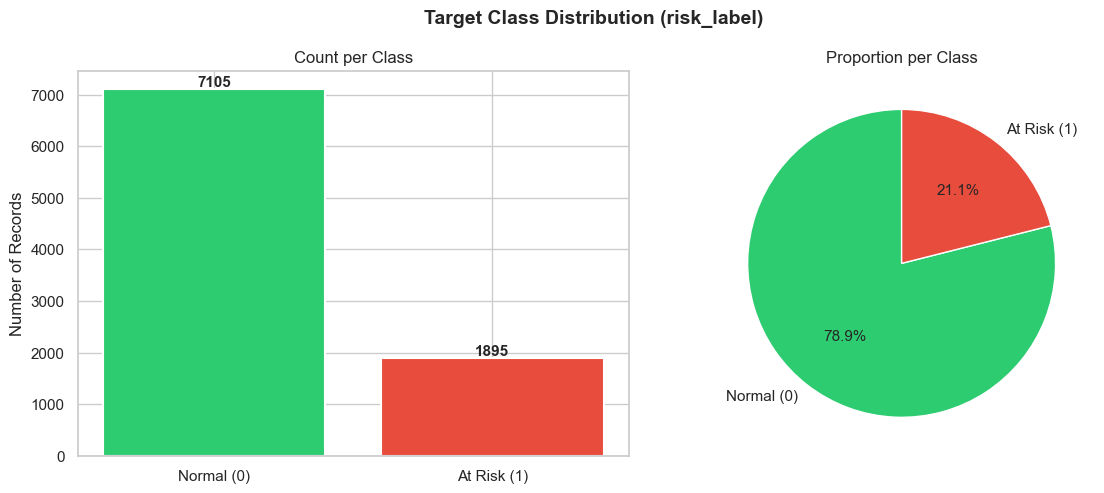


⚠ Class imbalance detected (ratio = 0.27)
  Consider using class_weight or SMOTE when training


In [7]:
print("\n" + "=" * 60)
print("SECTION 3 — TARGET CLASS DISTRIBUTION")
print("=" * 60)

counts = full_df['risk_label'].value_counts()
pcts   = full_df['risk_label'].value_counts(normalize=True) * 100

print(f"\nNormal  (0): {counts[0]} records  ({pcts[0]:.1f}%)")
print(f"At Risk (1): {counts[1]} records  ({pcts[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Class Distribution (risk_label)', fontsize=14, fontweight='bold')

# Bar chart
axes[0].bar(['Normal (0)', 'At Risk (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Count per Class')
axes[0].set_ylabel('Number of Records')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Normal (0)', 'At Risk (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Proportion per Class')

plt.tight_layout()
plt.savefig('visualizations/eda_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Check class imbalance
ratio = counts[1] / counts[0]
if ratio < 0.4 or ratio > 2.5:
    print(f"\n⚠ Class imbalance detected (ratio = {ratio:.2f})")
    print("  Consider using class_weight or SMOTE when training")
else:
    print(f"\nClasses are reasonably balanced (ratio = {ratio:.2f})")

VITAL SIGNS DISTRIBUTION


SECTION 4 — VITAL SIGNS DISTRIBUTION


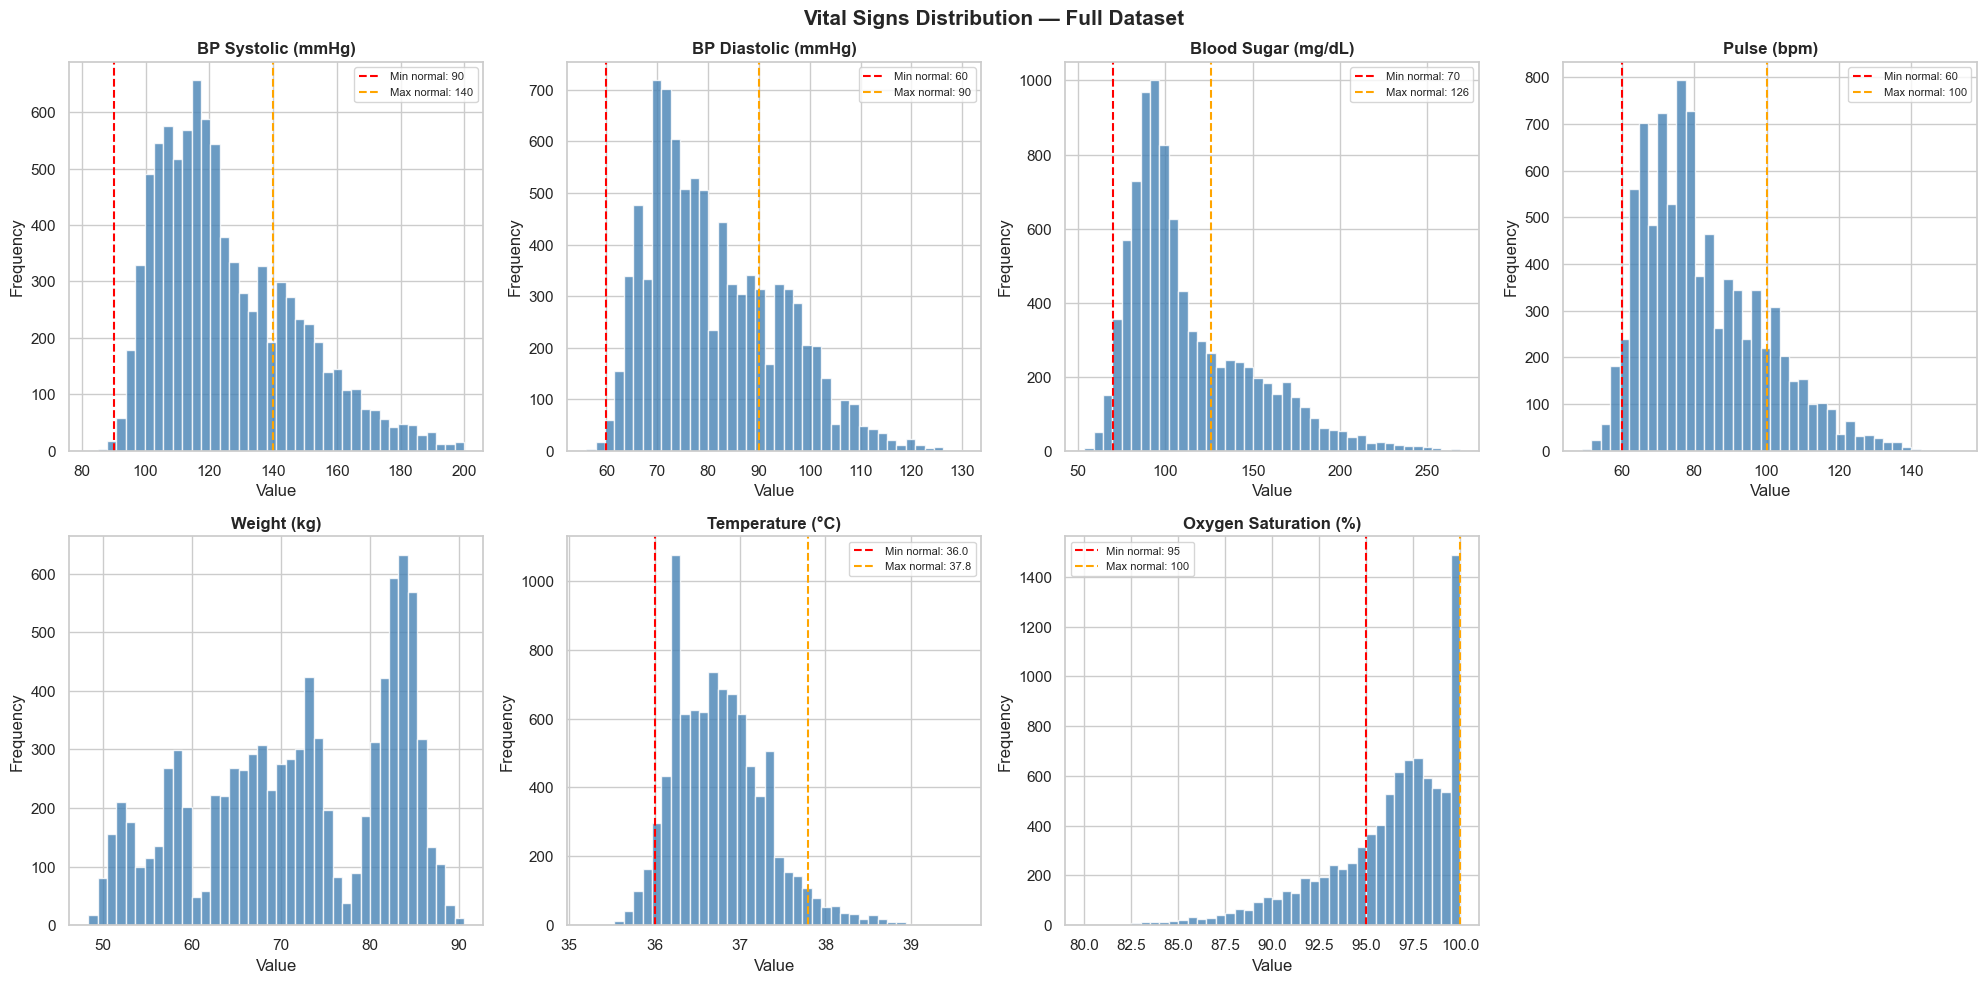

✓ Distribution charts generated

Mean values per vital sign:
blood_pressure_systolic     125.53
blood_pressure_diastolic     81.27
blood_sugar                 112.99
pulse                        82.01
weight                       71.83
temperature                  36.77
oxygen_saturation            96.12
dtype: float64


In [6]:
print("\n" + "=" * 60)
print("SECTION 4 — VITAL SIGNS DISTRIBUTION")
print("=" * 60)

# Normal ranges for reference lines
normal_ranges = {
    'blood_pressure_systolic':  (90, 140),
    'blood_pressure_diastolic': (60, 90),
    'blood_sugar':              (70, 126),
    'pulse':                    (60, 100),
    'temperature':              (36.0, 37.8),
    'oxygen_saturation':        (95, 100),
    'weight':                   (None, None),   # no fixed range
}

titles = {
    'blood_pressure_systolic':  'BP Systolic (mmHg)',
    'blood_pressure_diastolic': 'BP Diastolic (mmHg)',
    'blood_sugar':              'Blood Sugar (mg/dL)',
    'pulse':                    'Pulse (bpm)',
    'temperature':              'Temperature (°C)',
    'oxygen_saturation':        'Oxygen Saturation (%)',
    'weight':                   'Weight (kg)',
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Vital Signs Distribution — Full Dataset', fontsize=15, fontweight='bold')

for idx, col in enumerate(vital_cols):
    row, c = divmod(idx, 4)
    ax = axes[row][c]

    ax.hist(full_df[col], bins=40, color='steelblue',
            edgecolor='white', alpha=0.8)
    ax.set_title(titles[col], fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

    # Draw normal range lines
    lo, hi = normal_ranges[col]
    if lo:
        ax.axvline(lo, color='red', linestyle='--', linewidth=1.5, label=f'Min normal: {lo}')
    if hi:
        ax.axvline(hi, color='orange', linestyle='--', linewidth=1.5, label=f'Max normal: {hi}')
    if lo or hi:
        ax.legend(fontsize=8)

# Hide last empty subplot
axes[1][3].axis('off')

plt.tight_layout()
plt.savefig('visualizations/eda_vitals_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Distribution charts generated")
print("\nMean values per vital sign:")
print(full_df[vital_cols].mean().round(2))

OUTLIER DETECTION (Box Plots)


SECTION 5 — OUTLIER DETECTION


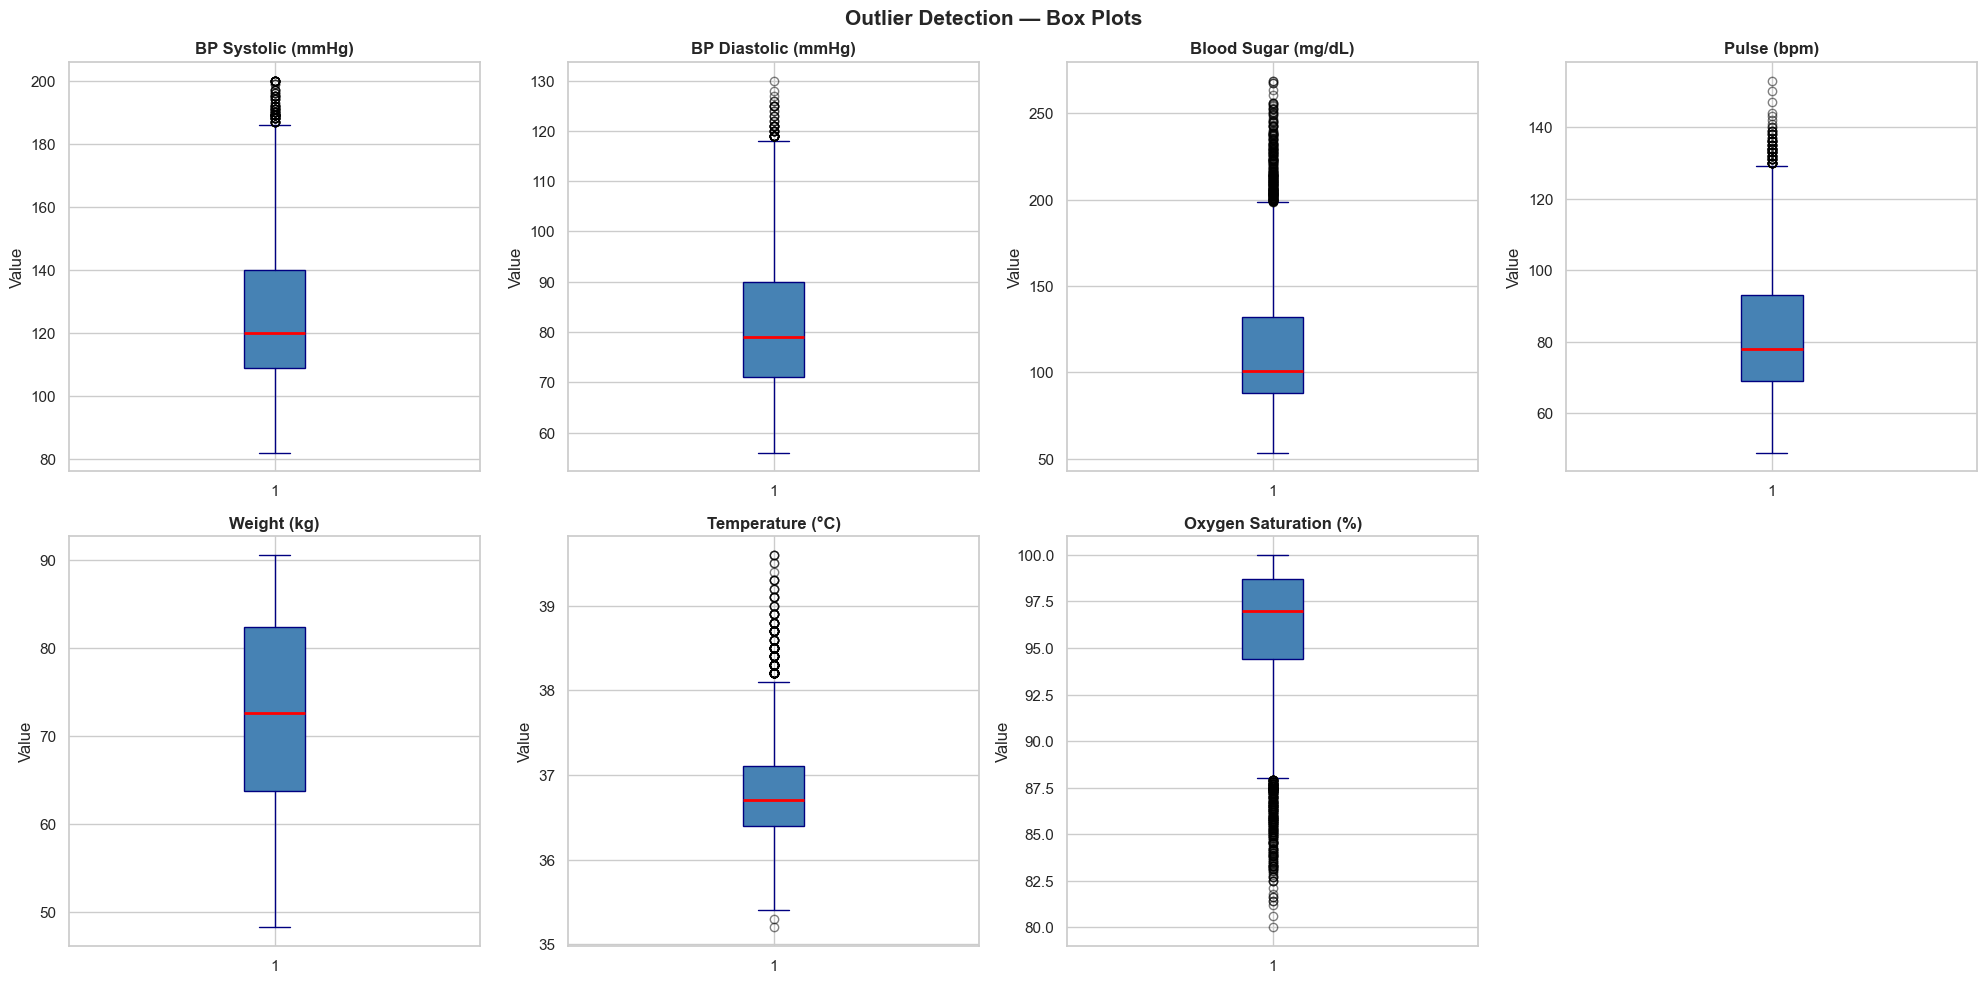


Outlier count per vital sign (IQR method):
  BP Systolic (mmHg)            : 92 outliers (1.0%)
  BP Diastolic (mmHg)           : 49 outliers (0.5%)
  Blood Sugar (mg/dL)           : 267 outliers (3.0%)
  Pulse (bpm)                   : 82 outliers (0.9%)
  Weight (kg)                   : 0 outliers (0.0%)
  Temperature (°C)              : 173 outliers (1.9%)
  Oxygen Saturation (%)         : 279 outliers (3.1%)


In [7]:
print("\n" + "=" * 60)
print("SECTION 5 — OUTLIER DETECTION")
print("=" * 60)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Outlier Detection — Box Plots', fontsize=15, fontweight='bold')

for idx, col in enumerate(vital_cols):
    row, c = divmod(idx, 4)
    ax = axes[row][c]

    ax.boxplot(full_df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', color='navy'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='navy'),
               capprops=dict(color='navy'),
               flierprops=dict(marker='o', color='red', alpha=0.5))
    ax.set_title(titles[col], fontweight='bold')
    ax.set_ylabel('Value')

axes[1][3].axis('off')

plt.tight_layout()
plt.savefig('visualizations/eda_outliers_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Count outliers using IQR method
print("\nOutlier count per vital sign (IQR method):")
for col in vital_cols:
    Q1  = full_df[col].quantile(0.25)
    Q3  = full_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = full_df[(full_df[col] < Q1 - 1.5 * IQR) |
                       (full_df[col] > Q3 + 1.5 * IQR)]
    pct = len(outliers) / len(full_df) * 100
    print(f"  {titles[col]:<30}: {len(outliers)} outliers ({pct:.1f}%)")

CORRELATION ANALYSIS


SECTION 6 — CORRELATION ANALYSIS

Correlation matrix:
                          blood_pressure_systolic  blood_pressure_diastolic  \
blood_pressure_systolic                      1.00                      0.72   
blood_pressure_diastolic                     0.72                      1.00   
blood_sugar                                  0.71                      0.73   
pulse                                        0.76                      0.72   
weight                                       0.15                      0.25   
temperature                                  0.48                      0.48   
oxygen_saturation                           -0.73                     -0.67   
risk_label                                   0.64                      0.63   

                          blood_sugar  pulse  weight  temperature  \
blood_pressure_systolic          0.71   0.76    0.15         0.48   
blood_pressure_diastolic         0.73   0.72    0.25         0.48   
blood_sugar               

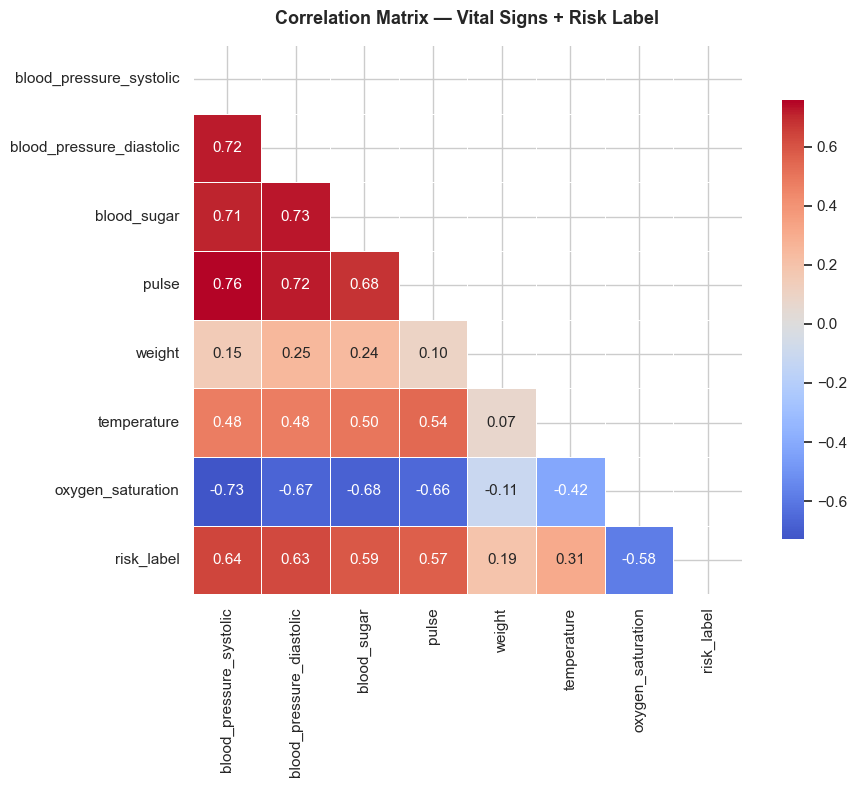


Correlation with risk_label (strongest predictors):
blood_pressure_systolic     0.64
blood_pressure_diastolic    0.63
blood_sugar                 0.59
oxygen_saturation           0.58
pulse                       0.57
temperature                 0.31
weight                      0.19
Name: risk_label, dtype: float64

✓ Most correlated with risk: blood_pressure_systolic (0.64)


In [8]:
print("\n" + "=" * 60)
print("SECTION 6 — CORRELATION ANALYSIS")
print("=" * 60)

corr_cols = vital_cols + ['risk_label']
corr_matrix = full_df[corr_cols].corr().round(2)

print("\nCorrelation matrix:")
print(corr_matrix)

# Heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # hide upper triangle
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            mask=mask,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Vital Signs + Risk Label',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('visualizations/eda_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelation with risk_label (strongest predictors):")
risk_corr = corr_matrix['risk_label'].drop('risk_label').abs().sort_values(ascending=False)
print(risk_corr)
print(f"\n✓ Most correlated with risk: {risk_corr.index[0]} ({risk_corr.iloc[0]:.2f})")

VITAL SIGNS BY RISK LABEL


SECTION 7 — VITAL SIGNS BY RISK LABEL


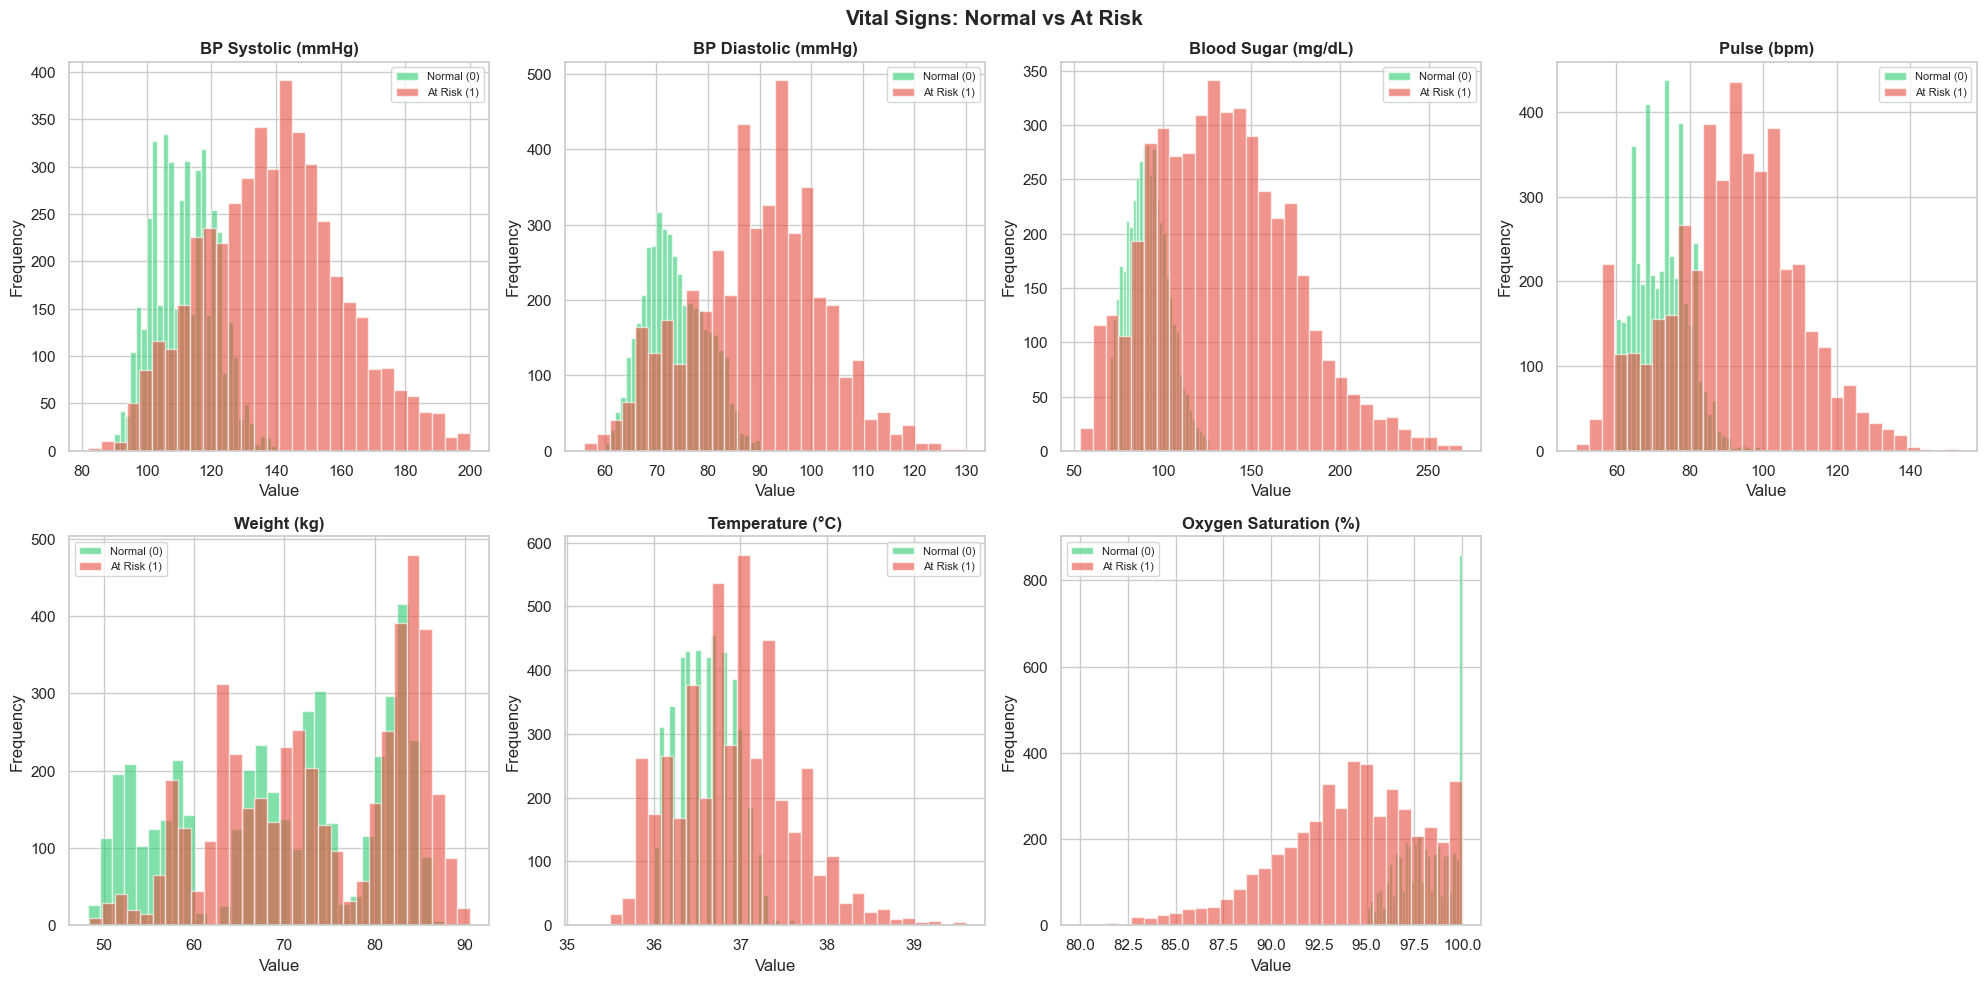


Mean vital signs — Normal vs At Risk:
                          Normal (0)  At Risk (1)
blood_pressure_systolic       111.37       139.25
blood_pressure_diastolic       73.06        89.23
blood_sugar                    91.67       133.64
pulse                          72.44        91.28
weight                         69.73        73.86
temperature                    36.59        36.94
oxygen_saturation              98.15        94.14


In [9]:
print("\n" + "=" * 60)
print("SECTION 7 — VITAL SIGNS BY RISK LABEL")
print("=" * 60)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Vital Signs: Normal vs At Risk', fontsize=15, fontweight='bold')

normal_data  = full_df[full_df['risk_label'] == 0]
risk_data    = full_df[full_df['risk_label'] == 1]

for idx, col in enumerate(vital_cols):
    row, c = divmod(idx, 4)
    ax = axes[row][c]

    ax.hist(normal_data[col], bins=30, alpha=0.6,
            color='#2ecc71', label='Normal (0)', edgecolor='white')
    ax.hist(risk_data[col],   bins=30, alpha=0.6,
            color='#e74c3c', label='At Risk (1)', edgecolor='white')
    ax.set_title(titles[col], fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

axes[1][3].axis('off')

plt.tight_layout()
plt.savefig('visualizations/eda_vitals_by_risk.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMean vital signs — Normal vs At Risk:")
comparison = full_df.groupby('risk_label')[vital_cols].mean().round(2)
comparison.index = ['Normal (0)', 'At Risk (1)']
print(comparison.T)

RESIDENT-LEVEL ANALYSIS


SECTION 8 — RESIDENT-LEVEL ANALYSIS

Total residents: 50

Top 10 highest-risk residents:
             total_readings  risk_readings  risk_pct  avg_bp_systolic  \
resident_id                                                             
1                       180            180     100.0           156.84   
2                       180            180     100.0           157.18   
4                       180            180     100.0           150.70   
6                       180            180     100.0           153.49   
10                      180            180     100.0           153.67   
11                      180            180     100.0           143.58   
15                      180            180     100.0           163.47   
17                      180            180     100.0           136.96   
13                      180            180     100.0           145.92   
19                      180            180     100.0           143.44   

             avg_blood_sugar  avg

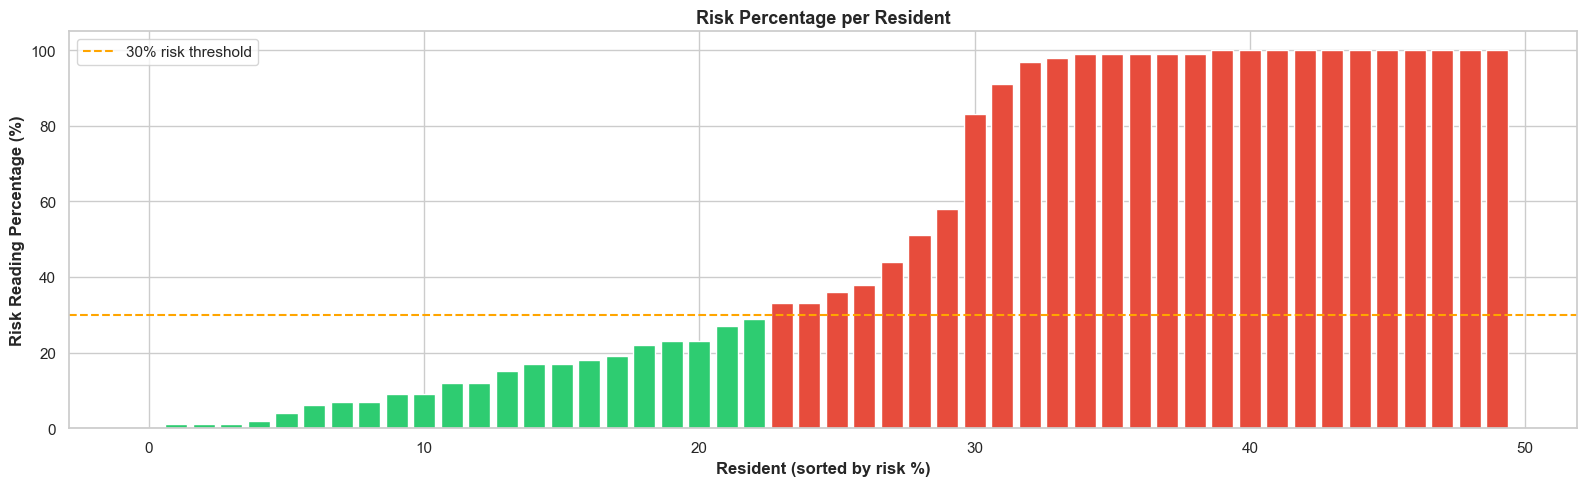

In [10]:
print("\n" + "=" * 60)
print("SECTION 8 — RESIDENT-LEVEL ANALYSIS")
print("=" * 60)

resident_summary = full_df.groupby('resident_id').agg(
    total_readings   = ('risk_label', 'count'),
    risk_readings    = ('risk_label', 'sum'),
    risk_pct         = ('risk_label', 'mean'),
    avg_bp_systolic  = ('blood_pressure_systolic', 'mean'),
    avg_blood_sugar  = ('blood_sugar', 'mean'),
    avg_pulse        = ('pulse', 'mean'),
    avg_oxygen_sat   = ('oxygen_saturation', 'mean')
).round(2)

resident_summary['risk_pct'] = (resident_summary['risk_pct'] * 100).round(1)

print(f"\nTotal residents: {len(resident_summary)}")
print(f"\nTop 10 highest-risk residents:")
print(resident_summary.sort_values('risk_pct', ascending=False).head(10))
print(f"\nTop 10 lowest-risk residents:")
print(resident_summary.sort_values('risk_pct').head(10))

# Plot risk % per resident
plt.figure(figsize=(16, 5))
sorted_res = resident_summary.sort_values('risk_pct')
colors = ['#e74c3c' if p > 30 else '#2ecc71' for p in sorted_res['risk_pct']]
plt.bar(range(len(sorted_res)), sorted_res['risk_pct'], color=colors)
plt.axhline(30, color='orange', linestyle='--', linewidth=1.5, label='30% risk threshold')
plt.xlabel('Resident (sorted by risk %)', fontweight='bold')
plt.ylabel('Risk Reading Percentage (%)', fontweight='bold')
plt.title('Risk Percentage per Resident', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('visualizations/eda_resident_risk.png', dpi=300, bbox_inches='tight')
plt.show()

TIME-BASED PATTERNS


SECTION 9 — TIME-BASED PATTERNS


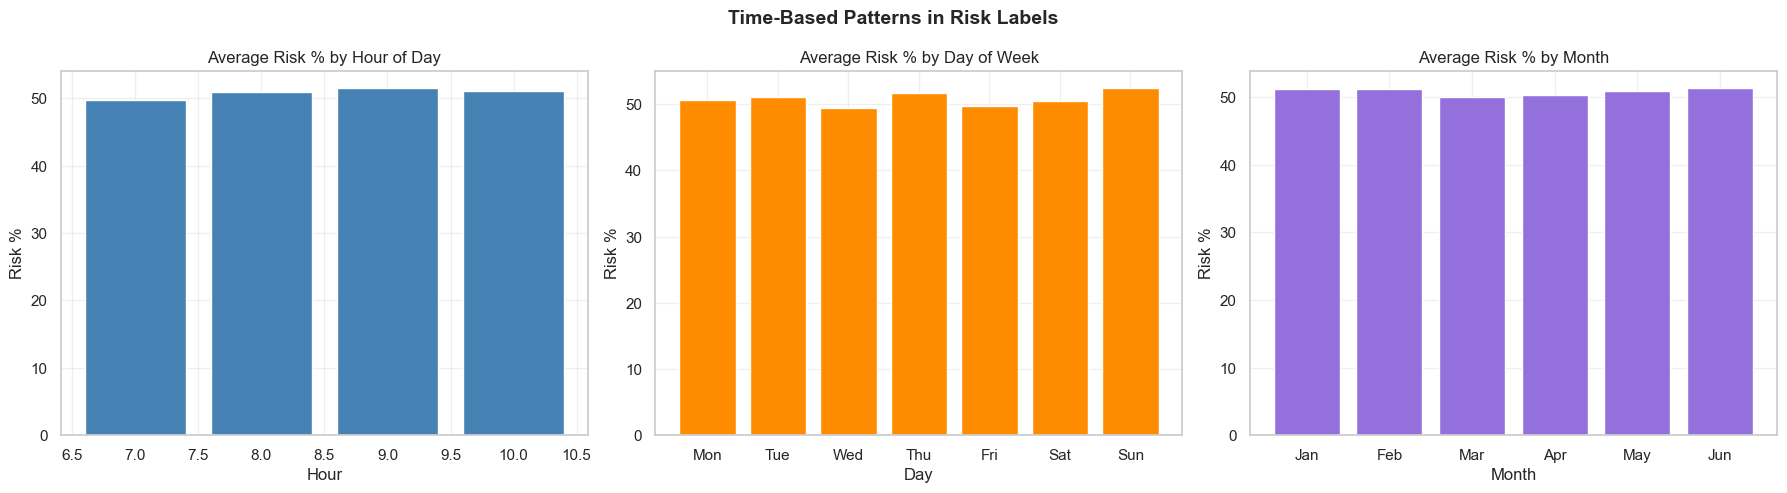

In [11]:
print("\n" + "=" * 60)
print("SECTION 9 — TIME-BASED PATTERNS")
print("=" * 60)

# Extract time features
full_df['hour']        = full_df['logged_at'].dt.hour
full_df['day_of_week'] = full_df['logged_at'].dt.dayofweek
full_df['month']       = full_df['logged_at'].dt.month

day_names   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Time-Based Patterns in Risk Labels', fontsize=14, fontweight='bold')

# By hour
hour_risk = full_df.groupby('hour')['risk_label'].mean() * 100
axes[0].bar(hour_risk.index, hour_risk.values, color='steelblue', edgecolor='white')
axes[0].set_title('Average Risk % by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Risk %')
axes[0].grid(True, alpha=0.3)

# By day of week
dow_risk = full_df.groupby('day_of_week')['risk_label'].mean() * 100
axes[1].bar(range(len(dow_risk)), dow_risk.values, color='darkorange', edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].set_title('Average Risk % by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Risk %')
axes[1].grid(True, alpha=0.3)

# By month
month_risk = full_df.groupby('month')['risk_label'].mean() * 100
axes[2].bar(range(len(month_risk)), month_risk.values, color='mediumpurple', edgecolor='white')
axes[2].set_xticks(range(len(month_risk)))
axes[2].set_xticklabels([month_names[m-1] for m in month_risk.index])
axes[2].set_title('Average Risk % by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Risk %')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/eda_time_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

SAMPLE RESIDENT TIME SERIES

#Shows how one resident's vitals change over time


SECTION 10 — SAMPLE RESIDENT TIME SERIES


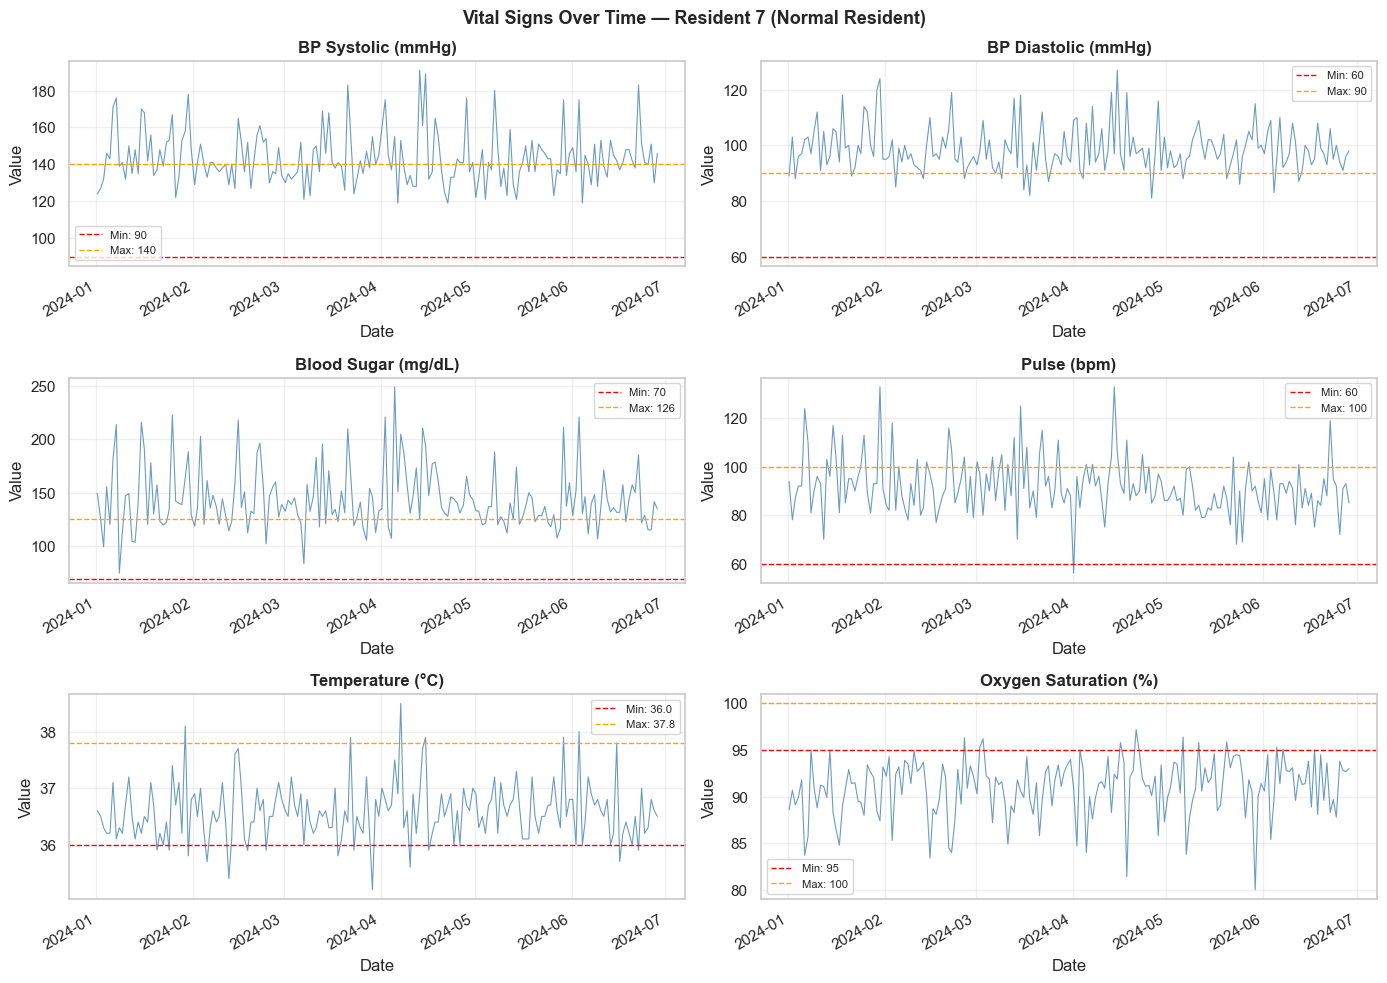

Saved: visualizations/eda_timeseries_resident_7.png


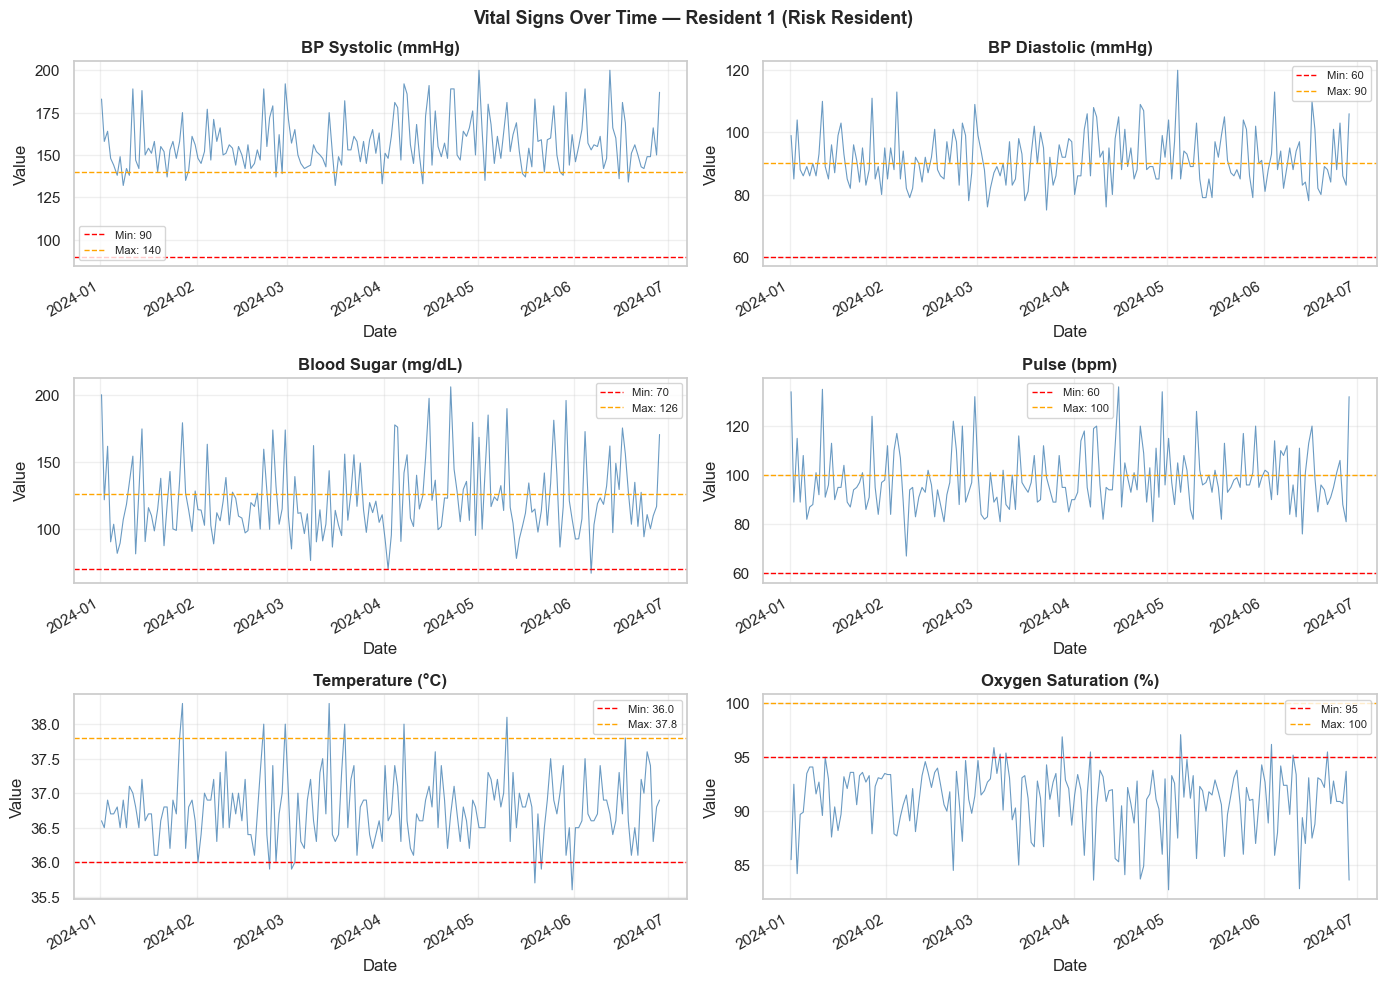

Saved: visualizations/eda_timeseries_resident_1.png


In [12]:
print("\n" + "=" * 60)
print("SECTION 10 — SAMPLE RESIDENT TIME SERIES")
print("=" * 60)

# Pick one normal and one risk resident
normal_res  = full_df[full_df['risk_label'] == 0]['resident_id'].value_counts().index[-1]
risk_res    = full_df[full_df['risk_label'] == 1]['resident_id'].value_counts().index[0]

for res_id, label in [(normal_res, 'Normal Resident'), (risk_res, 'Risk Resident')]:
    res_data = full_df[full_df['resident_id'] == res_id].sort_values('logged_at')

    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    fig.suptitle(f'Vital Signs Over Time — Resident {res_id} ({label})',
                 fontsize=13, fontweight='bold')

    vitals_to_plot = [
        ('blood_pressure_systolic',  'BP Systolic (mmHg)',   90, 140),
        ('blood_pressure_diastolic', 'BP Diastolic (mmHg)',  60, 90),
        ('blood_sugar',              'Blood Sugar (mg/dL)',  70, 126),
        ('pulse',                    'Pulse (bpm)',          60, 100),
        ('temperature',              'Temperature (°C)',     36.0, 37.8),
        ('oxygen_saturation',        'Oxygen Saturation (%)', 95, 100),
    ]

    for idx, (col, title, lo, hi) in enumerate(vitals_to_plot):
        row, c = divmod(idx, 2)
        ax = axes[row][c]
        ax.plot(res_data['logged_at'], res_data[col],
                color='steelblue', linewidth=0.8, alpha=0.8)
        ax.axhline(lo, color='red',    linestyle='--', linewidth=1, label=f'Min: {lo}')
        ax.axhline(hi, color='orange', linestyle='--', linewidth=1, label=f'Max: {hi}')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Value')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    fname = f"visualizations/eda_timeseries_resident_{res_id}.png"
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

TRAIN VS TEST COMPARISON

#Verifies train and test sets have similar distributions

In [13]:
print("\n" + "=" * 60)
print("SECTION 11 — TRAIN vs TEST COMPARISON")
print("=" * 60)

print(f"\nTrain risk label distribution:")
print(train_df['risk_label'].value_counts())
print(f"Train risk %: {train_df['risk_label'].mean()*100:.1f}%")

print(f"\nTest risk label distribution:")
print(test_df['risk_label'].value_counts())
print(f"Test risk %:  {test_df['risk_label'].mean()*100:.1f}%")

print(f"\nMean vital signs — Train vs Test:")
comparison = pd.DataFrame({
    'Train': train_df[vital_cols].mean().round(2),
    'Test':  test_df[vital_cols].mean().round(2)
})
print(comparison)

diff = abs(comparison['Train'] - comparison['Test'])
if diff.max() < 5:
    print("\n✓ Train and test distributions are similar — good split!")
else:
    print("\n⚠ Some differences between train and test — check split")


SECTION 11 — TRAIN vs TEST COMPARISON

Train risk label distribution:
risk_label
1    4298
0    2902
Name: count, dtype: int64
Train risk %: 59.7%

Test risk label distribution:
risk_label
0    1527
1     273
Name: count, dtype: int64
Test risk %:  15.2%

Mean vital signs — Train vs Test:
                           Train    Test
blood_pressure_systolic   129.85  108.22
blood_pressure_diastolic   83.73   71.44
blood_sugar               118.18   92.22
pulse                      84.77   70.95
weight                     72.28   70.02
temperature                36.82   36.57
oxygen_saturation          95.49   98.61

⚠ Some differences between train and test — check split


EDA SUMMARY

In [14]:
print("\n" + "=" * 60)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 60)

print(f"""
Dataset Overview:
  - Total records:   {len(full_df)}
  - Total residents: {full_df['resident_id'].nunique()}
  - Date range:      {full_df['logged_at'].min().date()} to {full_df['logged_at'].max().date()}
  - Features used:   {len(vital_cols)} vital signs + time features

Class Distribution:
  - Normal  (0): {full_df['risk_label'].value_counts()[0]} records ({full_df['risk_label'].value_counts(normalize=True)[0]*100:.1f}%)
  - At Risk (1): {full_df['risk_label'].value_counts()[1]} records ({full_df['risk_label'].value_counts(normalize=True)[1]*100:.1f}%)

Data Quality:
  - Missing values: {full_df[vital_cols].isnull().sum().sum()}
  - All vital signs within realistic human ranges

Strongest Predictors of Risk:
  {risk_corr.head(3).to_string()}

Charts saved to visualizations/ folder:
  - eda_class_distribution.png
  - eda_vitals_distribution.png
  - eda_outliers_boxplot.png
  - eda_correlation_heatmap.png
  - eda_vitals_by_risk.png
  - eda_resident_risk.png
  - eda_time_patterns.png
  - eda_timeseries_resident_X.png

✓ EDA Complete! You can now proceed to train_models.ipynb
""")


EDA SUMMARY — KEY FINDINGS

Dataset Overview:
  - Total records:   9000
  - Total residents: 50
  - Date range:      2024-01-01 to 2024-06-28
  - Features used:   7 vital signs + time features

Class Distribution:
  - Normal  (0): 4429 records (49.2%)
  - At Risk (1): 4571 records (50.8%)

Data Quality:
  - Missing values: 0
  - All vital signs within realistic human ranges

Strongest Predictors of Risk:
  blood_pressure_systolic     0.64
blood_pressure_diastolic    0.63
blood_sugar                 0.59

Charts saved to visualizations/ folder:
  - eda_class_distribution.png
  - eda_vitals_distribution.png
  - eda_outliers_boxplot.png
  - eda_correlation_heatmap.png
  - eda_vitals_by_risk.png
  - eda_resident_risk.png
  - eda_time_patterns.png
  - eda_timeseries_resident_X.png

✓ EDA Complete! You can now proceed to train_models.ipynb

